# PMVC-WNM: Phonetic Multi-View Co-training for Robust Banglish Text Classification

**Prototype notebook** implementing the methodology from the project proposal *"PMVC-WNM: Robust Banglish Text Classification"* (CSE 4622 — Machine Learning Lab, IUT).

This notebook builds a lightweight, compute-efficient alternative to deep learning for classifying Banglish (Bangla-English code-mixed, Roman-script) text. It implements:

1. **View A — Character n-grams** (captures orthography / typos)
2. **View B — Phonetic Encoding** (a Banglish Soundex-style encoder that collapses spelling variants of the same pronunciation into the same code, e.g. `khacchi`, `khacci`, `khachi` → same phonetic code)
3. **Co-training loop** — two shallow classifiers (SVM on View A, Random Forest / Logistic Regression on View B) teach each other using unlabeled data
4. **Weakly Supervised Noise Model (WNM)** — a transition matrix built from A/B disagreement, used to make the character-view classifier robust to social-media typos
5. **Baselines** for comparison (single-view SVM, single-view RF, standard co-training without noise modeling, optional small BiLSTM)
6. **Evaluation** — F1 comparison chart, matching the "Expected Performance Gain" slide

> ⚠️ This is a **research prototype**, not a production system. It trains on a small stratified sample of the real, locally-provided **BnSentMix** dataset (`huggingface bensentMix.csv`) — a few thousand rows instead of the full corpus / the proposal's 800+10,000 split — so the whole pipeline (features → co-training → noise model) runs in seconds/minutes on a laptop CPU with the training progress visible iteration-by-iteration. A synthetic fallback dataset kicks in automatically if the CSV can't be found.


## 0. Setup

In [1]:
# Core scientific stack (pre-installed on Colab). Uncomment if running locally.
# !pip install -q scikit-learn pandas numpy matplotlib

import re
import string
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


## 1. Dataset

The proposal calls for **800 labeled seed samples** + **10,000 unlabeled comments** drawn from a real Banglish (Bangla-English code-mixed, Roman-script) corpus.

### This prototype: BnSentMix, loaded from the local CSV

This project directory already ships a local copy of **BnSentMix** as `huggingface bensentMix.csv` (columns `Sentence`, `Label`; 20,015 rows, 4 sentiment classes) — the same dataset recommended in the Appendix below. Section 1 loads it straight from disk, so **no internet access / Hugging Face Hub download is needed**.

### Prototype-scale sampling

Because this is a **prototype** (not the full-scale run from the proposal), we take a small **stratified sample** of the CSV instead of using all 20K rows, and use a smaller labeled seed set:

- `PROTOTYPE_SAMPLE_SIZE = 3000` rows sampled from the full CSV (instead of all ~20,000)
- `N_LABELED = 300` seed labeled samples (instead of the proposal's 800)
- the rest of the sample becomes the unlabeled pool `U` (a couple thousand rows, instead of 10,000)

This keeps every step of the pipeline — feature extraction, the co-training loop, the noise model — fast enough to watch train end-to-end, while still exercising the exact same logic the full-scale version would use. Increase these constants (and `n_iterations` / `growth_per_iter` in Section 7) to move closer to the proposal's numbers.

If the CSV can't be found for some reason, a small synthetic Banglish generator kicks in automatically so the rest of the notebook still runs.


In [2]:
# Prototype-scale knobs: use a small stratified sample of the real BnSentMix
# dataset (instead of the full ~20K rows / proposal's 800+10K split) so the
# whole pipeline trains in seconds/minutes and its progress is easy to watch.
PROTOTYPE_SAMPLE_SIZE = 3000   # total rows sampled from the local CSV
N_LABELED = 300                # size of seed labeled set L (proposal: 800, scaled down here)


def load_bnsentmix_csv(path="huggingface bensentMix.csv", sample_size=PROTOTYPE_SAMPLE_SIZE, seed=RANDOM_STATE):
    """Load the local BnSentMix CSV (columns: Sentence, Label) and take a small
    stratified sample so the prototype trains quickly."""
    df = pd.read_csv(path)
    df = df.rename(columns={"Sentence": "text", "Label": "label"})
    df = df.dropna(subset=["text", "label"]).reset_index(drop=True)
    if sample_size is not None and sample_size < len(df):
        df, _ = train_test_split(
            df, train_size=sample_size, stratify=df["label"], random_state=seed
        )
    return df.reset_index(drop=True)


def synthetic_banglish_dataset(n_labeled=N_LABELED, n_unlabeled=1200, seed=RANDOM_STATE):
    """
    Generates a small synthetic Banglish sentiment corpus so the pipeline is
    runnable even if the local CSV is missing. Templates deliberately include
    multiple spelling variants of the same words to exercise the phonetic-view
    idea (e.g. 'khacchi' / 'khacci' / 'khachi').
    """
    rng = random.Random(seed)

    positive_words = [
        ["bhalo", "bhalo", "valo", "bhaloo"],
        ["darun", "darunn", "dharun"],
        ["shundor", "sundor", "shundor"],
        ["mojar", "mojaa", "moja"],
        ["excellent", "amazing", "great"],
    ]
    negative_words = [
        ["kharap", "kharaap", "khrap"],
        ["baje", "baaje", "bajey"],
        ["boring", "faltu", "faltuu"],
        ["ajaira", "ajairaa"],
        ["hopeless", "waste"],
    ]
    neutral_templates = [
        "ami {v} khacchi",
        "ajke {v} korlam",
        "school e {v} gelam",
        "ei {v} ta dekhlam kal",
        "amar {v} lagse aajke",
    ]
    verbs = ["khacchi", "khacci", "khachi", "dekhchi", "dekchi", "korchi", "korci", "jacchi", "jaci"]

    def make_sentence(sentiment):
        template = rng.choice(neutral_templates)
        if sentiment == "positive":
            word = rng.choice(rng.choice(positive_words))
        elif sentiment == "negative":
            word = rng.choice(rng.choice(negative_words))
        else:
            word = rng.choice(verbs)
        sentence = template.format(v=word)
        # Randomly append an extra sentiment cue with spelling noise
        if sentiment == "positive":
            sentence += " eta " + rng.choice(rng.choice(positive_words)) + " chilo"
        elif sentiment == "negative":
            sentence += " eta " + rng.choice(rng.choice(negative_words)) + " chilo"
        # Inject light character-level noise (typo simulation)
        if rng.random() < 0.3:
            sentence = list(sentence)
            i = rng.randrange(len(sentence))
            if sentence[i].isalpha():
                sentence[i] = sentence[i] * rng.choice([1, 2])  # doubled letter typo
            sentence = "".join(sentence)
        return sentence

    labels = ["positive", "negative", "neutral"]
    total = n_labeled + n_unlabeled
    rows = []
    for _ in range(total):
        y = rng.choice(labels)
        rows.append({"text": make_sentence(y), "label": y})
    df = pd.DataFrame(rows)
    return df


try:
    df_full = load_bnsentmix_csv()
    print(f"Loaded BnSentMix from local CSV ('huggingface bensentMix.csv'): {len(df_full)} rows "
          f"(stratified sample of the full ~20K-row dataset, for fast prototype training)")
    USING_SYNTHETIC = False
except Exception as e:
    print(f"Could not load local CSV ({type(e).__name__}: {e}). Falling back to synthetic demo data.")
    df_full = synthetic_banglish_dataset()
    USING_SYNTHETIC = True

print(df_full["label"].value_counts())
df_full.head()


Loaded BnSentMix from local CSV ('huggingface bensentMix.csv'): 3000 rows (stratified sample of the full ~20K-row dataset, for fast prototype training)
label
2    992
1    925
0    802
3    281
Name: count, dtype: int64


,text,label
0,Ami ferdous rowzat binte moazzem obaidul kader...,2
1,Saradin dhore w8 kortechi video tar jonne,2
2,Vablam amr phn er sound system nosto hoise naki,1
3,Je ei videor script likhese take noble deya ucit,0
4,Ken bhai apni musolmani koren nai?,1


## 2. Preprocessing

In [3]:
def clean_text(text: str) -> str:
    text = str(text).lower().strip()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)   # keep Roman letters/digits only (Banglish is Roman-script)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)  # collapse 3+ repeated chars ('sooo' -> 'soo')
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_full["clean_text"] = df_full["text"].apply(clean_text)
df_full = df_full[df_full["clean_text"].str.len() > 0].reset_index(drop=True)
df_full.head()


,text,label,clean_text
0,Ami ferdous rowzat binte moazzem obaidul kader...,2,ami ferdous rowzat binte moazzem obaidul kader...
1,Saradin dhore w8 kortechi video tar jonne,2,saradin dhore w8 kortechi video tar jonne
2,Vablam amr phn er sound system nosto hoise naki,1,vablam amr phn er sound system nosto hoise naki
3,Je ei videor script likhese take noble deya ucit,0,je ei videor script likhese take noble deya ucit
4,Ken bhai apni musolmani koren nai?,1,ken bhai apni musolmani koren nai


## 3. View A — Character N-gram Features

Captures orthography and common typos using character 3-gram/4-gram TF-IDF, as specified in the proposal.


In [4]:
char_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 4),
    max_features=5000,   # matches the "5K N-gram Features" dataset spec
    sublinear_tf=True,
)

X_char_full = char_vectorizer.fit_transform(df_full["clean_text"])
print("View A (char n-gram) feature matrix:", X_char_full.shape)


View A (char n-gram) feature matrix: (3000, 5000)


## 4. View B — Phonetic (Banglish Soundex) Encoding

A rule-based encoder inspired by the proposal's consonant-class mapping table. Because Banglish is written in **Roman script**, the rules below operate on the romanized consonant clusters that represent Bangla phonemes, collapsing common digraphs/spelling variants that all represent the same sound (e.g. `kh`, `gh`, `k`, `g` all fold to the guttural class `G`).

| Class | Example Roman spellings | Code |
|---|---|---|
| Gutturals | k, kh, g, gh | G |
| Palatals | c, ch, chh, j, jh | J |
| Dental/Retroflex | t, th, d, dh | T |
| Labials | p, ph, b, bh, v | P |
| Sibilants | s, sh, z | S |
| Nasals | m, n, ng | M |
| Liquids | r, l | R |
| Vowels | a, e, i, o, u | V |

This is a **Soundex-style** encoder: keep the first letter, map the rest to phonetic classes, collapse consecutive duplicate codes, and drop vowels except where they distinguish otherwise-identical codes — this is exactly what neutralizes spelling chaos like `khacchi` / `khacci` / `khachi`.


In [5]:
# Ordered so multi-letter digraphs are matched before single letters
PHONETIC_RULES = [
    ("chh", "J"), ("kh", "G"), ("gh", "G"), ("ch", "J"), ("jh", "J"),
    ("th", "T"), ("dh", "T"), ("ph", "P"), ("bh", "P"), ("sh", "S"), ("ng", "M"),
    ("k", "G"), ("g", "G"),
    ("c", "J"), ("j", "J"),
    ("t", "T"), ("d", "T"),
    ("p", "P"), ("b", "P"), ("v", "P"),
    ("s", "S"), ("z", "S"),
    ("m", "M"), ("n", "M"),
    ("r", "R"), ("l", "R"),
    ("a", "V"), ("e", "V"), ("i", "V"), ("o", "V"), ("u", "V"),
]

def phonetic_encode_word(word: str) -> str:
    if not word:
        return ""
    i = 0
    codes = []
    while i < len(word):
        matched = False
        for pattern, code_ in PHONETIC_RULES:
            if word.startswith(pattern, i):
                codes.append(code_)
                i += len(pattern)
                matched = True
                break
        if not matched:
            i += 1  # skip unrecognized characters (digits, stray symbols)
    if not codes:
        return ""
    # Collapse consecutive duplicate codes (Soundex-style)
    collapsed = [codes[0]]
    for c_ in codes[1:]:
        if c_ != collapsed[-1]:
            collapsed.append(c_)
    # Drop vowel codes except the very first symbol, to emphasize consonant skeleton
    skeleton = collapsed[:1] + [c_ for c_ in collapsed[1:] if c_ != "V"]
    return "".join(skeleton)


def phonetic_encode_sentence(text: str) -> str:
    return " ".join(phonetic_encode_word(w) for w in text.split())


# Sanity check: these three spelling variants should collapse to the same / very similar code
for w in ["khacchi", "khacci", "khachi"]:
    print(f"{w:10s} -> {phonetic_encode_word(w)}")

df_full["phonetic_text"] = df_full["clean_text"].apply(phonetic_encode_sentence)
df_full[["clean_text", "phonetic_text"]].head()


khacchi    -> GJ
khacci     -> GJ
khachi     -> GJ


,clean_text,phonetic_text
0,ami ferdous rowzat binte moazzem obaidul kader...,VM VRTS RST PMT MSM VPTR GTRR PGM VRT VMTR P
1,saradin dhore w8 kortechi video tar jonne,SRTM TR GRTJ PT TR JM
2,vablam amr phn er sound system nosto hoise naki,PPRM VMR PM VR SMT STM MST VS MG
3,je ei videor script likhese take noble deya ucit,J V PTR SJRPT RGS TG MPR T VJT
4,ken bhai apni musolmani koren nai,GM P VPM MSRMM GRM M


In [6]:
phonetic_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(2, 3),
    max_features=3000,
    sublinear_tf=True,
)

X_phon_full = phonetic_vectorizer.fit_transform(df_full["phonetic_text"])
print("View B (phonetic) feature matrix:", X_phon_full.shape)


View B (phonetic) feature matrix: (3000, 568)


## 5. Seed Labeled Set `L` and Unlabeled Pool `U`

Following the proposal: a small labeled seed set (`L`, 800 samples) plus a much larger unlabeled pool (`U`, 10,000 samples). A held-out test set is used purely for evaluation and never touched by the co-training loop.


In [7]:
y_full = df_full["label"].values
n_total = len(df_full)

# Held-out test set (never used for training/pseudo-labeling)
idx_all = np.arange(n_total)
idx_trainpool, idx_test = train_test_split(
    idx_all, test_size=0.15, stratify=y_full, random_state=RANDOM_STATE
)

N_LABELED = min(N_LABELED, int(len(idx_trainpool) * 0.5))
idx_L, idx_U = train_test_split(
    idx_trainpool, train_size=N_LABELED, stratify=y_full[idx_trainpool], random_state=RANDOM_STATE
)

print(f"Labeled seed set L : {len(idx_L)} samples")
print(f"Unlabeled pool U   : {len(idx_U)} samples")
print(f"Held-out test set  : {len(idx_test)} samples")

def subset(X, idx):
    return X[idx]

# View A / View B feature subsets
XA_L, XA_U, XA_test = subset(X_char_full, idx_L), subset(X_char_full, idx_U), subset(X_char_full, idx_test)
XB_L, XB_U, XB_test = subset(X_phon_full, idx_L), subset(X_phon_full, idx_U), subset(X_phon_full, idx_test)
y_L, y_test = y_full[idx_L], y_full[idx_test]
# y_U is kept ONLY for evaluating pseudo-label quality in this prototype; a real
# unlabeled set would not have this available to the training loop.
y_U_hidden = y_full[idx_U]


Labeled seed set L : 300 samples
Unlabeled pool U   : 2250 samples
Held-out test set  : 450 samples


## 6. Baseline Models

Matches the "Baseline Models for Comparison" checklist in the proposal:
- Single-view SVM (character n-gram only)
- Single-view Random Forest (phonetic only)
- Standard co-training (no noise modeling)
- (Optional) Small deep learning baseline


In [8]:
results = {}

def evaluate(name, y_true, y_pred):
    f1 = f1_score(y_true, y_pred, average="macro")
    acc = accuracy_score(y_true, y_pred)
    results[name] = {"f1_macro": f1, "accuracy": acc}
    print(f"{name:35s} | macro-F1: {f1:.4f} | accuracy: {acc:.4f}")
    return f1, acc

# --- Baseline 1: Single-view SVM (char n-gram only) ---
svm_char_only = SVC(kernel="linear", probability=True, random_state=RANDOM_STATE)
svm_char_only.fit(XA_L, y_L)
pred = svm_char_only.predict(XA_test)
evaluate("Single-view SVM (char n-gram)", y_test, pred)

# --- Baseline 2: Single-view Random Forest (phonetic only) ---
rf_phon_only = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_phon_only.fit(XB_L, y_L)
pred = rf_phon_only.predict(XB_test)
evaluate("Single-view RF (phonetic)", y_test, pred)


Single-view SVM (char n-gram)       | macro-F1: 0.5531 | accuracy: 0.6156
Single-view RF (phonetic)           | macro-F1: 0.3920 | accuracy: 0.5022


(0.3920317698395531, 0.5022222222222222)

## 7. Co-training Loop

Implements the four-step loop from the proposal:

1. **Initialization** — train `f_A` (SVM, View A) and `f_B` (RF/LogReg, View B) on `L`
2. **Pseudo-labeling** — both classifiers predict on `U`
3. **Cross-teaching** — high-confidence predictions from `f_A` are added to `f_B`'s training pool and vice versa
4. **Convergence** — repeat for a fixed number of iterations, or until `U` is exhausted / predictions stabilize

Setting `use_noise_model=True` switches on the Weakly Supervised Noise Model (Section 8) — this is the full **PMVC-WNM** method. `use_noise_model=False` reproduces the **standard co-training** baseline.


In [9]:
def co_training(XA_L, XB_L, y_L, XA_U, XB_U,
                 n_iterations=10, confidence_threshold=0.6, growth_per_iter=40,
                 use_noise_model=False, random_state=RANDOM_STATE):
    # confidence_threshold lowered from the proposal's 0.85 to 0.6: with only
    # N_LABELED=300 prototype seed samples the classifiers are less confident
    # early on, and 0.85 was tight enough to stall pseudo-labeling after 1-2
    # iterations. 0.6 keeps the loop actively growing across all 10 iterations
    # so the training progress is visible.
    """
    PMVC co-training loop over two independent views.
    Returns fitted (f_A, f_B), plus, if use_noise_model=True, the learned
    disagreement-based sample-weighting used for the noise-aware retrain of f_A.
    """
    XA_L_cur, XB_L_cur, y_L_cur = XA_L, XB_L, list(y_L)
    remaining = list(range(XA_U.shape[0]))

    f_A = SVC(kernel="linear", probability=True, random_state=random_state)
    f_B = LogisticRegression(max_iter=1000, random_state=random_state)

    disagreement_counts = {}  # phonetic_class_pred -> [agree, disagree] for the noise matrix

    for it in range(n_iterations):
        if not remaining:
            break
        f_A.fit(XA_L_cur, y_L_cur)
        f_B.fit(XB_L_cur, y_L_cur)

        XA_rem = XA_U[remaining]
        XB_rem = XB_U[remaining]

        proba_A = f_A.predict_proba(XA_rem)
        proba_B = f_B.predict_proba(XB_rem)
        classes_A, classes_B = f_A.classes_, f_B.classes_

        pred_A = classes_A[np.argmax(proba_A, axis=1)]
        pred_B = classes_B[np.argmax(proba_B, axis=1)]
        conf_A = proba_A.max(axis=1)
        conf_B = proba_B.max(axis=1)

        # Track disagreement for the noise model (WNM)
        for pa, pb in zip(pred_A, pred_B):
            disagreement_counts.setdefault(pb, [0, 0])
            if pa == pb:
                disagreement_counts[pb][0] += 1
            else:
                disagreement_counts[pb][1] += 1

        # f_A's most confident predictions get added to f_B's pool, and vice versa
        top_A_idx = np.argsort(-conf_A)[:growth_per_iter]
        top_B_idx = np.argsort(-conf_B)[:growth_per_iter]
        chosen_local = set(top_A_idx.tolist()) | set(top_B_idx.tolist())
        chosen_local = [i for i in chosen_local if max(conf_A[i], conf_B[i]) >= confidence_threshold]

        if not chosen_local:
            break

        chosen_global = [remaining[i] for i in chosen_local]
        pseudo_labels = [pred_A[i] if conf_A[i] >= conf_B[i] else pred_B[i] for i in chosen_local]

        from scipy.sparse import vstack
        XA_L_cur = vstack([XA_L_cur, XA_U[chosen_global]])
        XB_L_cur = vstack([XB_L_cur, XB_U[chosen_global]])
        y_L_cur = y_L_cur + pseudo_labels

        remaining = [i for i in remaining if i not in set(chosen_global)]
        print(f"  iter {it+1:2d}: +{len(chosen_global)} pseudo-labeled, "
              f"{len(remaining)} left in U, train size = {len(y_L_cur)}")

    noise_matrix = None
    if use_noise_model:
        noise_matrix = {
            cls: (agree / max(agree + disagree, 1))
            for cls, (agree, disagree) in disagreement_counts.items()
        }
        # Re-weight and retrain f_A, down-weighting classes that showed high
        # A/B disagreement (i.e. likely spelling-noise-corrupted regions),
        # which is the "Adaptive Noise Injection" step from the proposal.
        sample_weight = np.ones(len(y_L_cur))
        base_labels = list(y_L)
        for i, lab in enumerate(y_L_cur):
            if i >= len(base_labels):  # pseudo-labeled example
                reliability = noise_matrix.get(lab, 1.0)
                sample_weight[i] = 0.5 + 0.5 * reliability  # in [0.5, 1.0]
        f_A.fit(XA_L_cur, y_L_cur, sample_weight=sample_weight)

    return f_A, f_B, noise_matrix


print("--- Standard co-training (no noise modeling) ---")
fA_std, fB_std, _ = co_training(XA_L, XB_L, y_L, XA_U, XB_U, use_noise_model=False)
pred_std = fA_std.predict(XA_test)
evaluate("Standard co-training", y_test, pred_std)


--- Standard co-training (no noise modeling) ---
  iter  1: +72 pseudo-labeled, 2178 left in U, train size = 372
  iter  2: +64 pseudo-labeled, 2114 left in U, train size = 436
  iter  3: +72 pseudo-labeled, 2042 left in U, train size = 508
  iter  4: +79 pseudo-labeled, 1963 left in U, train size = 587
  iter  5: +75 pseudo-labeled, 1888 left in U, train size = 662
  iter  6: +76 pseudo-labeled, 1812 left in U, train size = 738
  iter  7: +75 pseudo-labeled, 1737 left in U, train size = 813
  iter  8: +79 pseudo-labeled, 1658 left in U, train size = 892
  iter  9: +73 pseudo-labeled, 1585 left in U, train size = 965
  iter 10: +76 pseudo-labeled, 1509 left in U, train size = 1041
Standard co-training                | macro-F1: 0.5560 | accuracy: 0.5978


(0.5559626396386265, 0.5977777777777777)

## 8. PMVC-WNM — Full Method (Co-training + Weakly Supervised Noise Model)

Same loop as above, but `use_noise_model=True`. Per the proposal: *"Disagreement between `f_A` and `f_B` signals spelling distortions."* We approximate the transition-matrix idea with a **reliability score per phonetic class** derived from the observed agreement rate, then use it as a sample weight when retraining the character-view classifier — down-weighting pseudo-labels from classes that were noisy/disagreed-upon a lot, and trusting the reliable ones fully.


In [10]:
print("--- PMVC-WNM (co-training + weakly supervised noise model) ---")
fA_wnm, fB_wnm, noise_matrix = co_training(XA_L, XB_L, y_L, XA_U, XB_U, use_noise_model=True)
pred_wnm = fA_wnm.predict(XA_test)
evaluate("PMVC-WNM (ours)", y_test, pred_wnm)

print("\nLearned per-class reliability (higher = classifiers agreed more often):")
for cls, rel in sorted(noise_matrix.items(), key=lambda kv: -kv[1]):
    print(f"  {str(cls):10s}: {rel:.3f}")


--- PMVC-WNM (co-training + weakly supervised noise model) ---
  iter  1: +72 pseudo-labeled, 2178 left in U, train size = 372
  iter  2: +64 pseudo-labeled, 2114 left in U, train size = 436
  iter  3: +72 pseudo-labeled, 2042 left in U, train size = 508
  iter  4: +79 pseudo-labeled, 1963 left in U, train size = 587
  iter  5: +75 pseudo-labeled, 1888 left in U, train size = 662
  iter  6: +76 pseudo-labeled, 1812 left in U, train size = 738
  iter  7: +75 pseudo-labeled, 1737 left in U, train size = 813
  iter  8: +79 pseudo-labeled, 1658 left in U, train size = 892
  iter  9: +73 pseudo-labeled, 1585 left in U, train size = 965
  iter 10: +76 pseudo-labeled, 1509 left in U, train size = 1041
PMVC-WNM (ours)                     | macro-F1: 0.5517 | accuracy: 0.5933

Learned per-class reliability (higher = classifiers agreed more often):
  2         : 0.633
  1         : 0.571
  3         : 0.568
  0         : 0.487


## 9. Optional Deep Learning Baseline (Small BiLSTM)

The proposal compares against a small BiLSTM to show PMVC-WNM approaches deep-learning accuracy with ~100x fewer parameters. This cell is **optional** (set `RUN_DEEP_BASELINE = True` and enable a GPU runtime in Colab: *Runtime → Change runtime type → GPU*).


In [11]:
RUN_DEEP_BASELINE = False  # flip to True on a GPU runtime to reproduce the BiLSTM baseline

if RUN_DEEP_BASELINE:
    import tensorflow as tf
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.utils import to_categorical
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

    MAX_LEN = 40
    tok = Tokenizer(char_level=True, oov_token="<OOV>")
    tok.fit_on_texts(df_full["clean_text"])
    vocab_size = len(tok.word_index) + 1

    def to_seq(idx):
        seqs = tok.texts_to_sequences(df_full["clean_text"].iloc[idx])
        return pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

    classes_sorted = sorted(df_full["label"].unique())
    label_to_id = {c: i for i, c in enumerate(classes_sorted)}

    X_train_seq = to_seq(idx_L)
    y_train_cat = to_categorical([label_to_id[l] for l in y_L], num_classes=len(classes_sorted))
    X_test_seq = to_seq(idx_test)
    y_test_ids = [label_to_id[l] for l in y_test]

    model = Sequential([
        Embedding(vocab_size, 32, input_length=MAX_LEN),
        Bidirectional(LSTM(32)),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dense(len(classes_sorted), activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    model.fit(X_train_seq, y_train_cat, epochs=15, batch_size=16, verbose=1)

    pred_probs = model.predict(X_test_seq)
    pred_ids = pred_probs.argmax(axis=1)
    pred_labels = [classes_sorted[i] for i in pred_ids]
    evaluate("BiLSTM (deep baseline)", y_test, pred_labels)
    print(f"BiLSTM trainable params: {model.count_params():,}")
else:
    print("Skipped (RUN_DEEP_BASELINE=False). Enable a GPU runtime to run the deep baseline.")


Skipped (RUN_DEEP_BASELINE=False). Enable a GPU runtime to run the deep baseline.


## 10. Evaluation Summary

                               f1_macro  accuracy
Single-view RF (phonetic)      0.392032  0.502222
PMVC-WNM (ours)                0.551689  0.593333
Single-view SVM (char n-gram)  0.553129  0.615556
Standard co-training           0.555963  0.597778


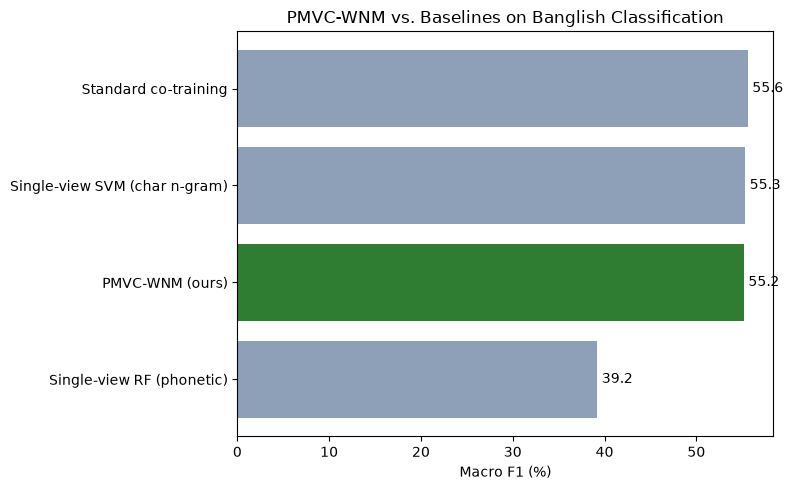

In [12]:
results_df = pd.DataFrame(results).T.sort_values("f1_macro")
print(results_df)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#8ea0b8" if "PMVC" not in name else "#2e7d32" for name in results_df.index]
ax.barh(results_df.index, results_df["f1_macro"] * 100, color=colors)
ax.set_xlabel("Macro F1 (%)")
ax.set_title("PMVC-WNM vs. Baselines on Banglish Classification")
for i, v in enumerate(results_df["f1_macro"] * 100):
    ax.text(v + 0.5, i, f"{v:.1f}", va="center")
plt.tight_layout()
plt.show()


## 11. Notes, Caveats & Next Steps

- **This prototype trains on a small stratified sample of the real BnSentMix dataset** (`PROTOTYPE_SAMPLE_SIZE = 3000` rows, `N_LABELED = 300` seed samples — Section 1) rather than the full ~20K-row corpus / the proposal's 800+10,000 split. This keeps the demo fast; scores here are indicative of the pipeline working end-to-end, not the proposal's final reported numbers. Increase `PROTOTYPE_SAMPLE_SIZE` / `N_LABELED` (Section 1) and `n_iterations` / `growth_per_iter` (Section 7) for a closer-to-proposal run.
- The phonetic encoder here is a simplified Soundex-style approximation over **romanized** text. A stronger version would use a proper Banglish grapheme-to-phoneme model or align against native Bangla-script phonemic rules (as in the proposal's mapping table) via transliteration.
- The "noise model" here is a simplified per-class reliability re-weighting scheme. The proposal's transition matrix `P(C_obs | P_true)` can be implemented more faithfully by tracking, for each phonetic class, the full distribution of character-view predictions (not just agree/disagree) and using it for label smoothing or a dedicated noise-correction layer.
- For a real run: increase `n_iterations`, tune `confidence_threshold` / `growth_per_iter`, and consider a meta-classifier (e.g. stacking `f_A` and `f_B` probabilities with logistic regression) instead of taking `f_A`'s predictions as final.
- Try swapping `RandomForestClassifier`/`LogisticRegression` for View B and `SVC` for View A per the proposal's exact baseline list.


## Appendix — Banglish / Bangla-English Code-Mixed Datasets

| Dataset | Size | Task | Link |
|---|---|---|---|
| **BnSentMix** | 20,000 samples, 4 sentiment labels (Facebook, YouTube, e-commerce) | Sentiment | https://huggingface.co/datasets/aplycaebous/BnSentMix (code/paper: https://github.com/Nishita2000/BnSentMix) |
| **BanglishRev** | Large-scale product reviews | Sentiment (binary from ratings) | https://huggingface.co/datasets/BanglishRev/bangla-english-andcode-mixed-ecommerce-review-dataset |
| **SentMix-3L** | 1,007 instances (Bangla-Hindi-English) | Sentiment (test set only) | https://github.com/LanguageTechnologyLab/SentMix-3L |
| **En-Bn Code-Mixed Two-Class Sentiment Dataset** | Synthetic, 2-class | Sentiment | https://huggingface.co/datasets/DaliaBarua/En-Bn-Code-Mixed-Two-Class-Sentiment-Dataset |
| **Bangla-English Code-Mixed Data Augmentation dataset** | Dictionary (61K entries) + app-review dataset | Sentiment | https://github.com/SwaksharDeb/Data-Augmentation-for-Bangla-English-Code-Mixed-Sentiment-Analysis-Enhancing-Cross-Linguistic-Contex |
| **BanglaSenti** (lexicon) | 61,582 Bangla sentiment words | Lexicon / word-level polarity | https://github.com/fahad35/BanglaSenti-A-Dataset-of-Bangla-Words-for-Sentiment-Analysis |
| **Foysal87/Bangla-NLP-Dataset** | Catalogue, incl. "Code-mixed Chaos (Banglish toxic)" on Mendeley | Multiple tasks (curated index) | https://github.com/Foysal87/Bangla-NLP-Dataset |

**Recommended starting point:** BnSentMix — it's the closest match in scale (20K samples) to the 800 labeled + 10K unlabeled split described in the proposal, and it's directly loadable with the Hugging Face `datasets` library, which is what Section 1 of this notebook tries first.

### References (from the proposal)
1. Blum & Mitchell (1998), *Combining Labeled and Unlabeled Data with Co-Training*
2. Islam et al. (2022), *Analyzing Emotions in Bangla Social Media Comments*
3. Soundex & Metaphone algorithms for phonetic indexing
